# Reinforcement Learning — Introduction & Comparaison d'algorithmes

## C'est quoi le RL ?

Le Reinforcement Learning, c'est apprendre par **essai-erreur** avec des récompenses.

```
        Action
Agent ---------> Environnement
  ^                    |
  |    Observation     |
  |    + Reward        |
  +--------------------+
```

**3 composants clés :**

- **Agent** : le cerveau (réseau de neurones)
- **Environnement** : le monde dans lequel il agit (ici LunarLander)
- **Reward** : signal de feedback (+100 si atterri, -100 si crash)

**La boucle :**

1. L'agent observe l'état (position, vitesse, angle...)
2. Il choisit une action (moteur gauche/droit/bas/rien)
3. L'environnement renvoie un nouveau state + reward
4. L'agent met à jour son réseau de neurones
5. Répéter jusqu'à convergence

---

## Algorithmes testés

| Algo    | Type       | Idée principale                                    |
| ------- | ---------- | -------------------------------------------------- |
| **PPO** | On-policy  | Limite les mises à jour trop grandes → stable      |
| **A2C** | On-policy  | Actor-Critic synchrone → rapide                    |
| **DQN** | Off-policy | Replay buffer + réseau cible → efficace en mémoire |


In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.evaluation import evaluate_policy

## Entraînement des 3 algorithmes

On entraîne chacun sur **50 000 steps** (rapide, juste pour comparer).


In [6]:
TIMESTEPS = 300_000
env = gym.make("LunarLander-v3")

models = {
    "PPO": PPO("MlpPolicy", env, verbose=0),
    "A2C": A2C("MlpPolicy", env, verbose=0),
    "DQN": DQN("MlpPolicy", env, verbose=0),
}

for name, model in models.items():
    print(f"Entraînement {name}...")
    model.learn(total_timesteps=TIMESTEPS)
    print(f"  {name} terminé")

env.close()
print("Entraînement terminé !")

Entraînement PPO...
  PPO terminé
Entraînement A2C...
  A2C terminé
Entraînement DQN...
  DQN terminé
Entraînement terminé !


## Évaluation & comparaison

`evaluate_policy` fait tourner l'agent N épisodes et retourne le score moyen.


In [7]:
eval_env = gym.make("LunarLander-v3")
results = {}

for name, model in models.items():
    mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10)
    results[name] = {"mean": mean_reward, "std": std_reward}
    print(f"{name:4s} — score moyen : {mean_reward:7.1f} ± {std_reward:.1f}")

eval_env.close()

PPO  — score moyen :     1.6 ± 106.3
A2C  — score moyen :  -103.8 ± 50.2
DQN  — score moyen :   -39.3 ± 90.8


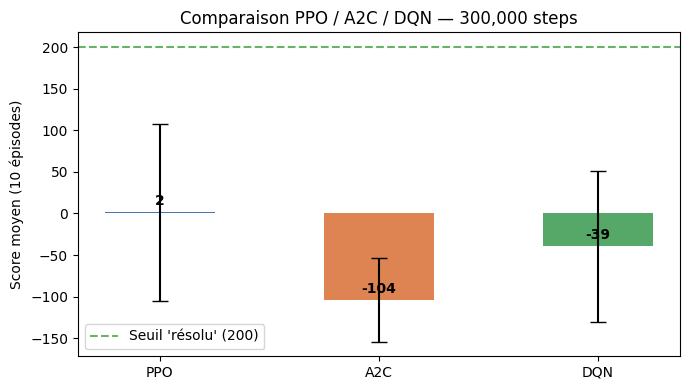

In [8]:
names = list(results.keys())
means = [results[n]["mean"] for n in names]
stds = [results[n]["std"] for n in names]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors, width=0.5)
ax.axhline(
    y=200, color="green", linestyle="--", alpha=0.6, label="Seuil 'résolu' (200)"
)
ax.set_ylabel("Score moyen (10 épisodes)")
ax.set_title(f"Comparaison PPO / A2C / DQN — {TIMESTEPS:,} steps")
ax.legend()

for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{mean:.0f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## Interprétation

- **Score > 200** = considéré "résolu" par gymnasium
- Avec seulement 50k steps, PPO converge généralement mieux que A2C et DQN sur LunarLander
- Pour vraiment résoudre le problème, il faut ~300k-500k steps

**Prochaines étapes :**

- Augmenter `TIMESTEPS` à 300_000 et relancer
- Sauvegarder un modèle : `model.save("ppo_lunar")`
- Charger et réutiliser : `model = PPO.load("ppo_lunar")`
